In [1]:
# Import Library & Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter

In [2]:
# Set Tema Visualisasi
sns.set_theme(style='whitegrid')

In [3]:
# Analisa Tren Pendapatan Bulanan

# Mengambil & Memuat data dari file csv tren pendapatan bulanan
path_trend = '../data/processed/monthly_revenue_trend.csv'
df_trend = pd.read_csv(path_trend)

In [4]:
# Memastikan data sudah masuk dengan mencetak data frame 10 index pertama
df_trend

,order_month,total_orders,total_revenue
0,2016-09,1,134.97
1,2016-10,265,40325.11
2,2016-12,1,10.90
3,2017-01,750,111798.36
4,2017-02,1653,234223.40
5,2017-03,2546,359198.85
6,2017-04,2303,340669.68
7,2017-05,3546,489338.25
8,2017-06,3135,421923.37
9,2017-07,3872,481604.52


In [5]:
# Cek struktur data table
df_trend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_month    23 non-null     object 
 1   total_orders   23 non-null     int64  
 2   total_revenue  23 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 684.0+ bytes


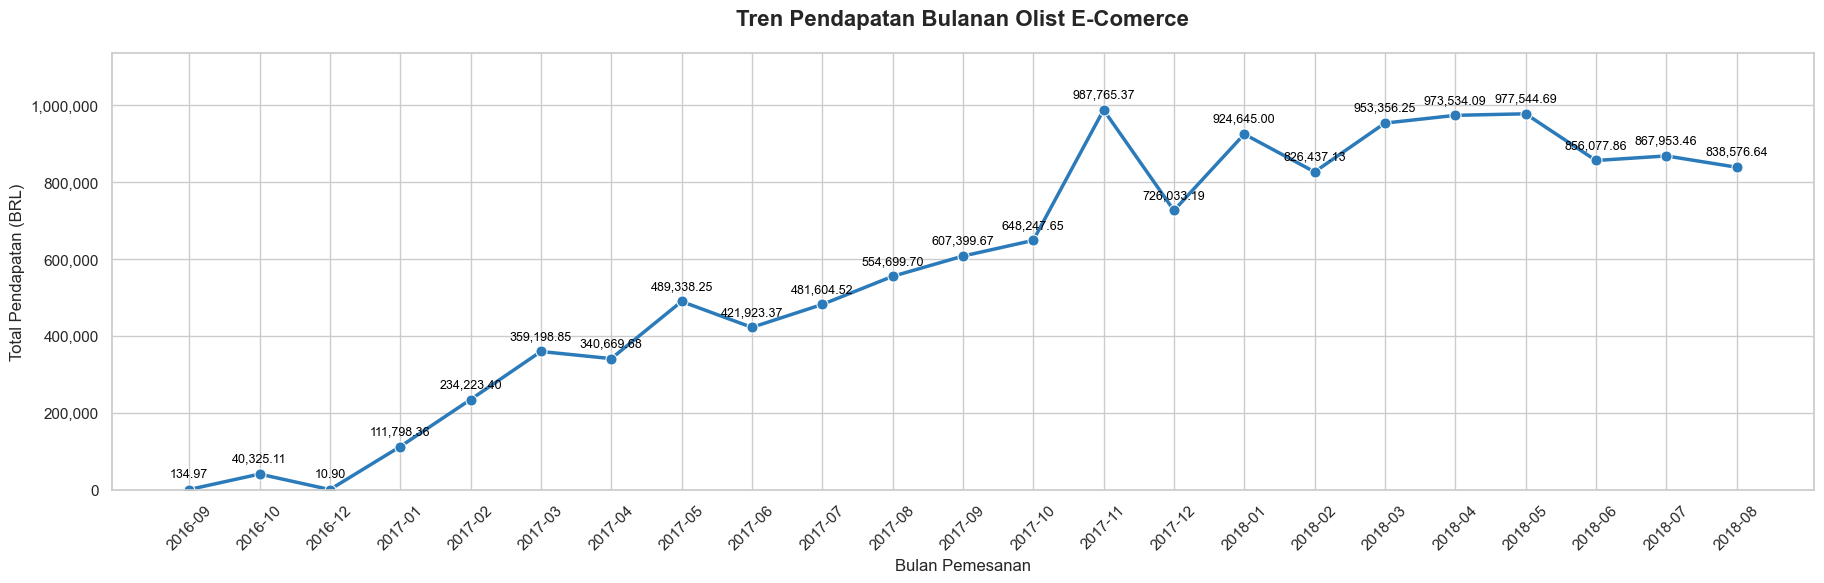

In [6]:
# Visualisasi Tren Pendapatan Bulanan (Line Chart)

# Membuat ukuran kanvas grafik responsive dengan menghitung bulan di dalam data
jumlah_bulan = len(df_trend)

# Menentukan lebar: misal 1 titik bulan butuh ruang 0.8 inci kita punya lebar data bulan 23 maka 23*0.8 hasil 18.4 inci maka lebar kanvas menjadi 18.4 inci
# Contoh : jumlah_bulan = 6 maka jumlah_bulan * 0.8 = 4.8 hasil max(15, 4.8) karena nilai dibawah min 15 yaitu 4.8 maka yang digunakan untuk lebar kanvas yaitu nilai 15
# Menentukan lebar minimal dengan max() dan nilai 15 inci
dynamic_width = max(15, jumlah_bulan * 0.8)

# Menerapkan lebar dinamis ke kanvas
plt.figure(figsize=(dynamic_width,6))

# plt.figure(figsize=(15,6))

# Membuat Line Chart dengan marker (titik) di setiap bulannya
ax = sns.lineplot(
  x = 'order_month',
  y = 'total_revenue',
  data = df_trend,
  marker = 'o', #Menambah titik di setiap bulan
  color = '#2b7bba', #Warna biru elegan
  linewidth = 2.5, #Ketebalan garis
  markersize = 8 #Ukuran Titik
  )

# Menambahkan judul & label sumbu grafik
plt.title('Tren Pendapatan Bulanan Olist E-Comerce', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Bulan Pemesanan', fontsize=12)
plt.ylabel('Total Pendapatan (BRL)', fontsize=12)

# Merotasi teks bulan di sumbu x sebanyak 45 derajat agar tidak bertumpuk
plt.xticks(rotation=45)

# Merubah angka di sumbu y menjadi format mata uang (Ribuan) agar mudah dibaca
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

# Menampilkan angka di atas titik data labels atau marker
for x, y in zip(df_trend['order_month'], df_trend['total_revenue']):
  plt.text(x, y + 25000, # Angka 25000 untuk menggeser teks sedikit ke atas titik
           f'{y:,.2f}', # Format angka dengan koma pemisah ribuan
           ha='center', # Teks rata tengah terhadap titik
           va='bottom', # Posisi di bawah kursor teks
           fontsize=9,
           color='black'
           )

# Mempertinggi bingkai atas (Sumbu Y) sebesar 15% agar teks tertinggi tidak terpotong
plt.ylim(0, df_trend['total_revenue'].max()*1.15)

# Merapikan tata letak agar tidak terpotong atau bertumpuk
plt.tight_layout()

# Menyiapkan grafik menjadi gambar png
plt.savefig('../data/processed/monthly_revenue_trend_chart.png', dpi=300)

# Menampilkan grafik
plt.show()

In [7]:
# MEMUAT DATA KATEGORI PRODUK (TOP & BOTTOM)

# Mengambil file data csv kategori produk
path_categories = '../data/processed/top_bottom_categories.csv'
df_categories = pd.read_csv(path_categories)

# Cek struktur kolom
df_categories.info()

# Menampilkan data table
df_categories

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   performance_group  10 non-null     object 
 1   product_category   10 non-null     object 
 2   total_items_sold   10 non-null     int64  
 3   total_revenue      10 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 452.0+ bytes


,performance_group,product_category,total_items_sold,total_revenue
0,Top 5 Highest,health_beauty,9465,1233131.72
1,Top 5 Highest,watches_gifts,5859,1166176.98
2,Top 5 Highest,bed_bath_table,10953,1023434.76
3,Top 5 Highest,sports_leisure,8431,954852.55
4,Top 5 Highest,computers_accessories,7644,888724.61
5,Bottom 5 Lowest,flowers,33,1110.04
6,Bottom 5 Lowest,home_comfort_2,30,760.27
7,Bottom 5 Lowest,cds_dvds_musicals,14,730.00
8,Bottom 5 Lowest,fashion_childrens_clothes,7,519.95
9,Bottom 5 Lowest,security_and_services,2,283.29


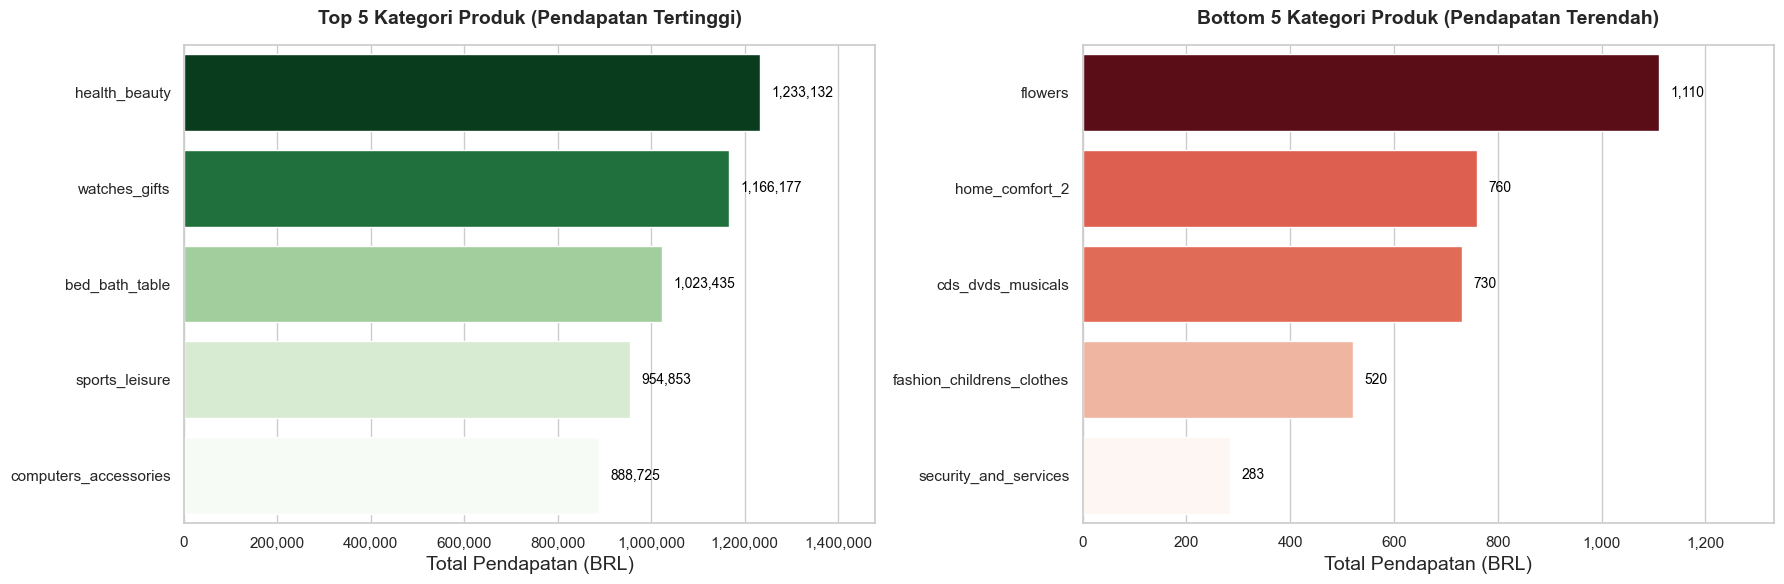

In [8]:
# VISUALISASI KATEGORI PRODUK (TOP & BOTTOM)

# Memisahkan data menjadi 2 data frame yaitu top dan bottom revenue
df_top = df_categories[df_categories['performance_group']=='Top 5 Highest']
df_bottom = df_categories[df_categories['performance_group']=='Bottom 5 Lowest']

# Membuat kanvas dengan 2 kolom grafik berdampingan (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Grafik Kiri Top 5 Revenue, Dengan axes[0] kita memilih grafik kiri untuk top revenue
sns.barplot(x='total_revenue',y='product_category', hue='total_revenue',data=df_top, ax=axes[0], palette='Greens', legend=False)
axes[0].set_title('Top 5 Kategori Produk (Pendapatan Tertinggi)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Total Pendapatan (BRL)',fontsize=14) #BRL artinya Brazilian Real (Mata Uang Brazil)
axes[0].set_ylabel('') # Menghilangkan label Y karena nama produk sudah jelas

# Menambahkan angka di ujung batang top 5
offset_top = df_top['total_revenue'].max()*0.02 #Jarak dinamis untuk teks
for p in axes[0].patches:
  width = p.get_width()
  axes[0].text(width + offset_top, p.get_y() + p.get_height()/2,
  f'{width:,.0f}',
  ha="left", va="center",fontsize=10, color='black')

# Memperlebar bingai grafik kiri pada bagian tepi kanan
axes[0].set_xlim(0, df_top['total_revenue'].max()*1.2)


# Grafik kanan bottom 5 Revenue, Dengan axes[1] kita memilih grafik kanan untuk bottom revenue
sns.barplot(x='total_revenue',y='product_category', hue='total_revenue',data=df_bottom, ax=axes[1], palette='Reds', legend=False)
axes[1].set_title('Bottom 5 Kategori Produk (Pendapatan Terendah)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Pendapatan (BRL)',fontsize=14) #BRL artinya Brazilian Real (Mata Uang Brazil)
axes[1].set_ylabel('') # Menghilangkan label Y karena nama produk sudah jelas

# Menambahkan angka di ujung batang bottom 5
offset_bottom = df_bottom['total_revenue'].max()*0.02 #Jarak dinamis untuk teks
for p in axes[1].patches:
  width = p.get_width()
  axes[1].text(width + offset_bottom, p.get_y() + p.get_height()/2,
  f'{width:,.0f}',
  ha="left", va="center",fontsize=10, color='black')

# Sumbu X ditampilkan tanpa scientific notation
formatter = FuncFormatter(lambda x, _: f'{int(x):,}')
axes[0].xaxis.set_major_formatter(formatter)
axes[1].xaxis.set_major_formatter(formatter)

# Memperlebar bingai grafik kanan pada bagian tepi kanan
axes[1].set_xlim(0, df_bottom['total_revenue'].max()*1.2)

# Merapihkan tata letak kedua grafik agar tidak menempel
plt.tight_layout()

# Simpan dalam png
plt.savefig('../data/processed/top_bottom_categories.png')

# Tampilkan
plt.show()

In [9]:
# Memuat Data Pengiriman & Kepuasan Pelanggan

# Mengambil file data delivery vs review
path_delivery = '../data/processed/delivery_vs_reviews.csv'
df_delivery = pd.read_csv(path_delivery)

In [10]:
# Cek struktur table dan kolom
df_delivery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   delivery_speed_category  4 non-null      object 
 1   total_order              4 non-null      int64  
 2   avg_review_score         4 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 228.0+ bytes


In [11]:
# Cek data kolom pada table
df_delivery

,delivery_speed_category,total_order,avg_review_score
0,1. Sangat Cepat (0-5 Hari),19229,4.43
1,2. Cepat (6-10 Hari),32850,4.35
2,3. Normal (11-15 Hari),21166,4.25
3,4. Lambat (> 15 Hari),23108,3.57


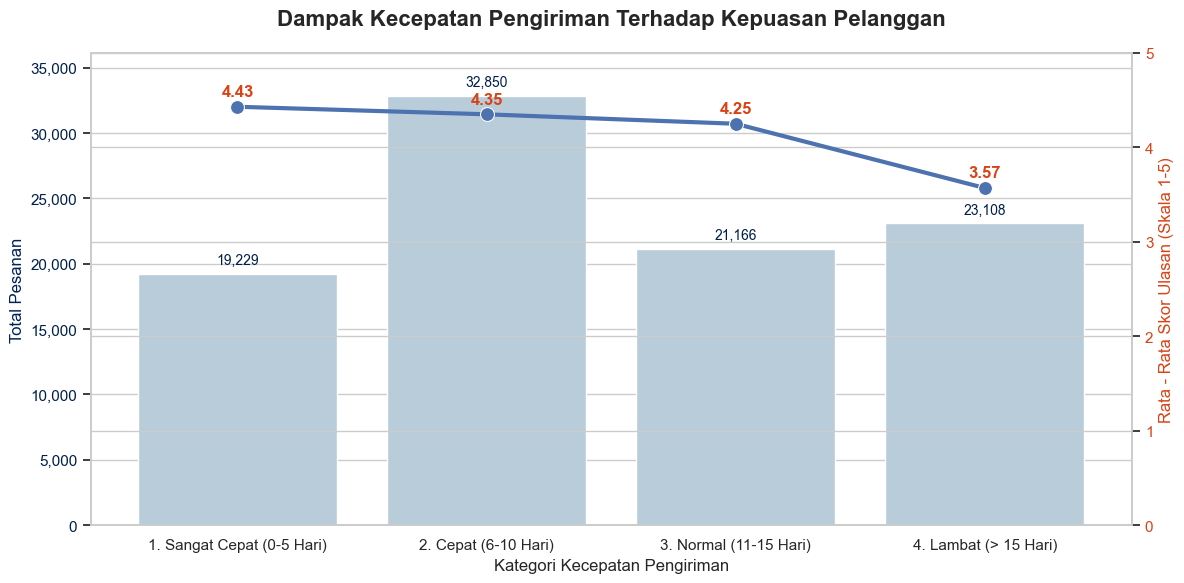

In [12]:
# VISUALISASI PENGIRIMAN VS KEPUASAN PELANGGAN

# Membuat kanvas
fig, ax1 =plt.subplots(figsize=(12,6))

# Grafik Batang Total Pesanan
sns.barplot(
  x='delivery_speed_category',
  y='total_order',
  data=df_delivery,
  color='#b3cde0', # Warna biru muda yang tidak terlalu mencolok
  ax=ax1
  )

ax1.set_title('Dampak Kecepatan Pengiriman Terhadap Kepuasan Pelanggan', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Kategori Kecepatan Pengiriman', fontsize=12)
ax1.set_ylabel('Total Pesanan', fontsize=12, color="#002357")
ax1.tick_params(axis='y', labelcolor='#011f4b') # Mewarnai label sumbu y

# Menambah koma untuk pemisah ribuan pada format y axis
formatter=FuncFormatter(lambda x, _: f'{int(x):,}')
ax1.yaxis.set_major_formatter(formatter)

# Membuat label text dinamis di atas grafik batang
for p in ax1.patches: 
  height = p.get_height()
  ax1.text(
  # Arti code p.get_x() yaitu ambil posisi kiri misal 10
  #p.get_width()/2 artinya ambil lebar bar misal 4 lalu jadi 2
  # Maka ditemukan posisi tengah == 10+2 = 12
  # angka 2. artinya bilangan float agar jika hasil bagi memiliki koma maka tidak dibulatkan
  p.get_x() + p.get_width()/2., height + 500,
  f'{int(height):,}',
  ha="center", va="bottom", fontsize=10, color='#011f4b'
  )

# Membuat kanvas grafik responsive tingginya dan tidak mepet text label di atas bar batang
ax1.set_ylim(0, df_delivery['total_order'].max()*1.1)


# MEMBUAT GRAFIK GARIS (RATA-RATA REVIEW)

# Membuat sumbu Y kanan (ax2) yang menempel dengan sumbu X
ax2 = ax1.twinx()

# Membuat grafik lineplot dari data review
sns.lineplot(
  x='delivery_speed_category',
  y='avg_review_score',
  data=df_delivery,
  marker='o',
  markersize=10,
  linewidth=3,
  ax=ax2
  )

# Membuat judul di sumbu y label kanan
ax2.set_ylabel('Rata - Rata Skor Ulasan (Skala 1-5)',fontsize=12, color='#d84315')
ax2.tick_params(axis='y', labelcolor='#d84315') # Warna teks sumbu Y kanan

# Menambahkan angka di atas titik grafik
for x, y in zip(range(len(df_delivery)), df_delivery['avg_review_score']):
  ax2.text(
    x,y + 0.08,
    f'{y:.2f}',
    ha='center', va='bottom', fontsize=12, fontweight='bold', color='#d84315'
    )

# Kita paksa batas sumbu Y kanan dari 1 sampai 5 (karena skor review bintang itu 1-5)
# Berhubung jika y axis dimulai dari 1 maka akan menumbuk data nilai bar dan line, jadi untuk menghindari tersebut y axis dimulai dari 0
ax2.set_ylim(0,5)

# Merapikan tata letak agar tidak terpotong atau bertumpuk
plt.tight_layout()

# Mencetak grafik ke png
plt.savefig('../data/processed/delivery_vs_reviews.png', dpi=300)

# Tampilkan
plt.show()